### Discutere la ricostruzione di un’immagine corrotta da blur e rumore, mostrando la soluzione naive, ottenuta risolvendo il problema dei minimi quadrati e la soluzione ottenuta con il metodo di regolarizzazione di Tikhonov. Mostrare inoltre le immagini ricostruite e i grafici dei parametri PSNR e MSE al variare del numero di iterazioni. Infine discutere i risultati al variare del parametro di regolarizzazione λ

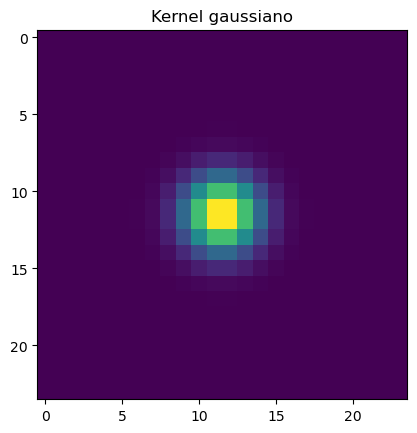

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, metrics
from scipy import signal
from numpy import fft
from utils_SR import psf_fft, A, AT, gaussian_kernel, totvar, grad_totvar

X = data.camera().astype(np.float64) / 255
m, n = X.shape

plt.title("Kernel gaussiano")
k = gaussian_kernel(24, 3)
plt.imshow(k)
plt.show()

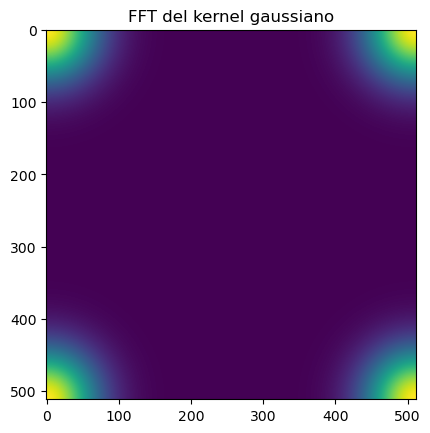

In [2]:
plt.title("FFT del kernel gaussiano")
K = psf_fft(k, 24, X.shape) 
plt.imshow(np.abs(K)) 
plt.show()

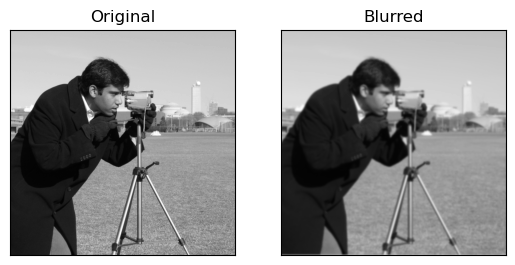

In [3]:
X_blurred = A(X, K, 1)   
plt.subplot(121).imshow(X, cmap='gray', vmin=0, vmax=1)
plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122).imshow(X_blurred, cmap='gray', vmin=0, vmax=1)
plt.title('Blurred')
plt.xticks([]), plt.yticks([])
plt.show()

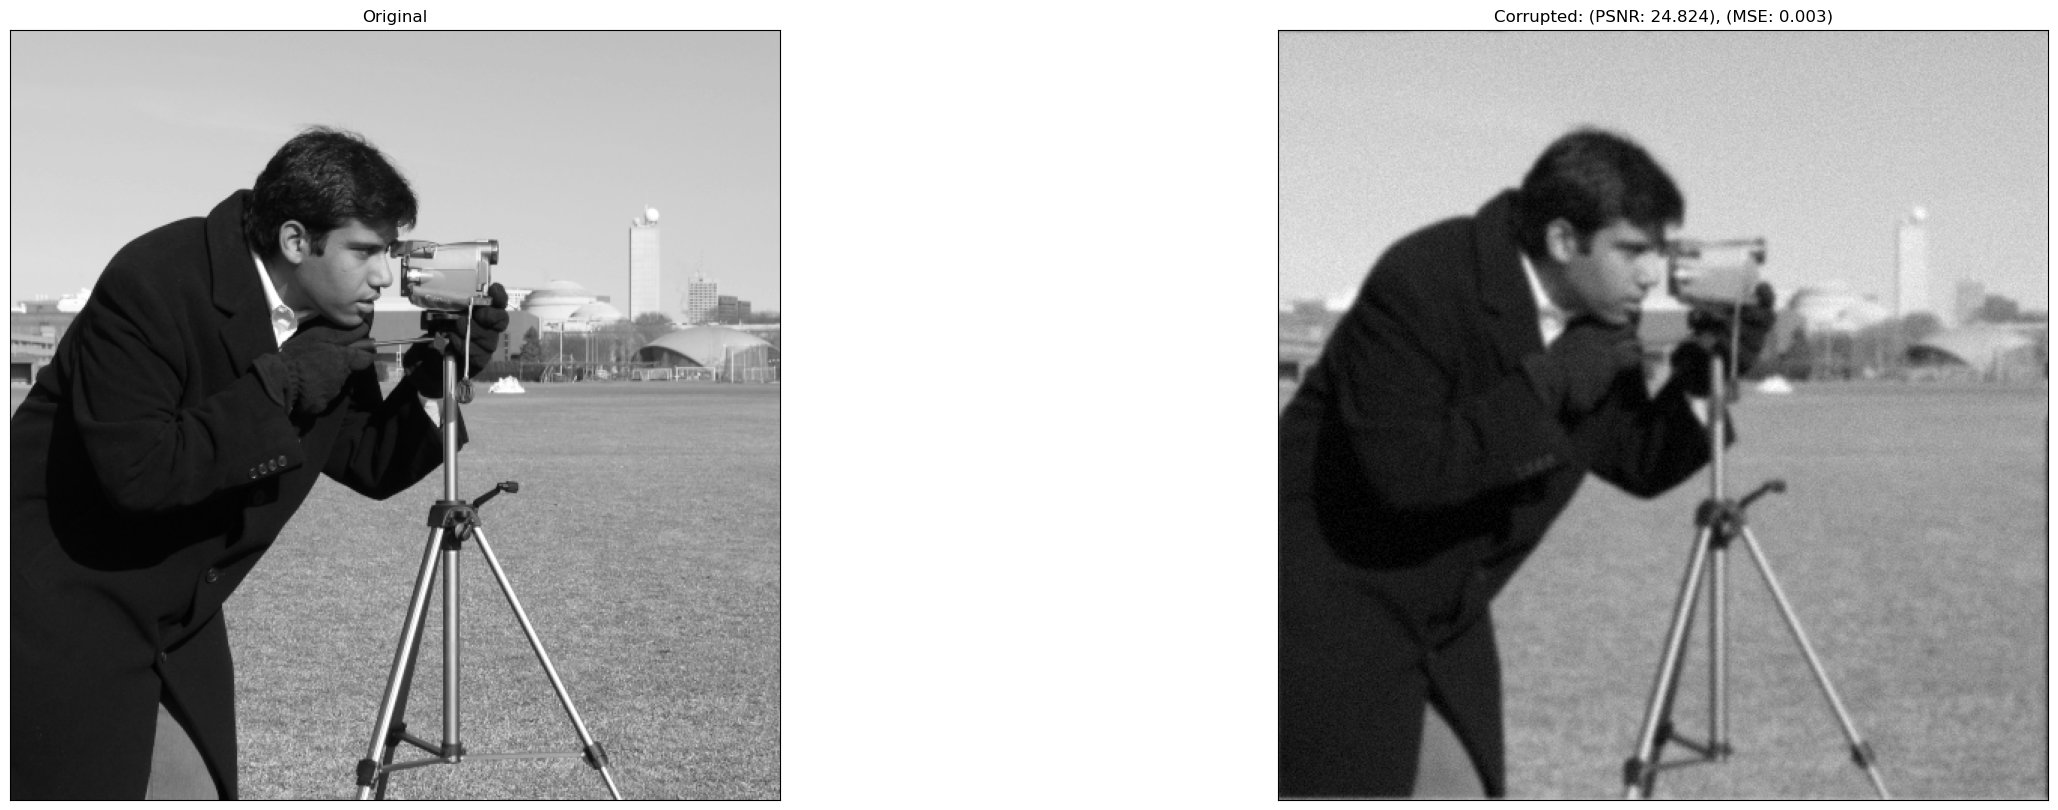

In [4]:
sigma = 0.02 
np.random.seed(42) 
noise = np.random.normal(size=X_blurred.shape) * sigma 

y = X_blurred + noise
ATy = AT(y, K, 1) 

PSNR = metrics.peak_signal_noise_ratio(X, ATy)
mse = metrics.mean_squared_error(X, ATy)

plt.figure(figsize=(30, 10))
plt.subplot(121).imshow(X, cmap='gray', vmin=0, vmax=1)
plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122).imshow(y, cmap='gray', vmin=0, vmax=1)
plt.title(f'Corrupted: (PSNR: {PSNR:.3f}), (MSE: {mse:.3f})')
plt.xticks([]), plt.yticks([])
plt.show()

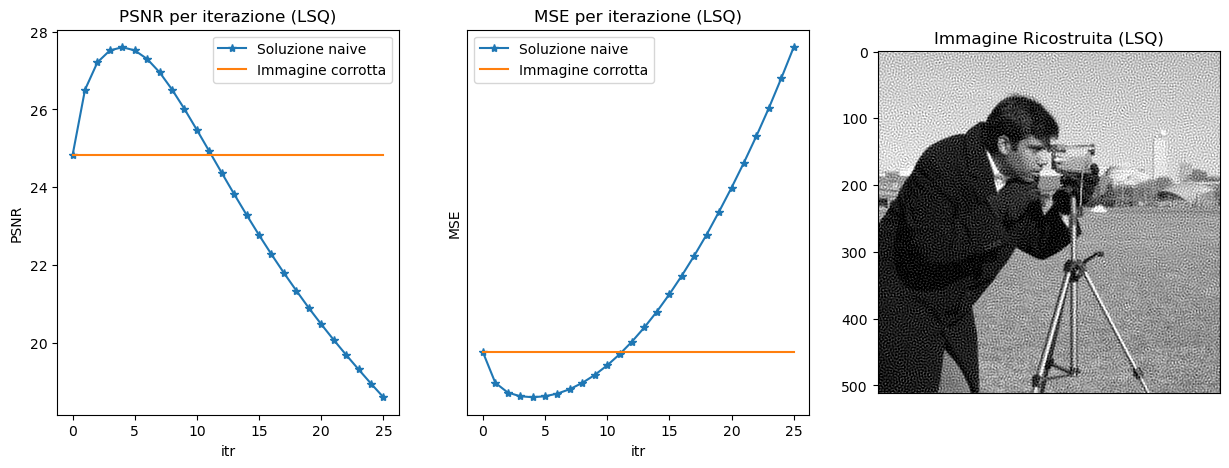

In [5]:
from scipy.optimize import minimize

def f(x):
    x = x.reshape((m, n)) 
    Ax = A(x, K, 1) 
    return 0.5 * np.sum(np.square(Ax - y)) 

def df(x):
    x = x.reshape((m, n))
    ATAx = AT(A(x, K, 1), K, 1) 
    d = ATAx - ATy
    return d.reshape(m * n) 

x0 = ATy.reshape(m * n) 
max_iter = 25
res = minimize(f, x0, method='CG', jac=df, options={'maxiter': max_iter, 'return_all': True}) 

PSNR = np.zeros(max_iter + 1) 
mse = np.zeros(max_iter + 1)

for k, x_k in enumerate(res.allvecs): 
    PSNR[k] = metrics.peak_signal_noise_ratio(X, x_k.reshape(X.shape)) 
    mse[k] = metrics.mean_squared_error(X, x_k.reshape(X.shape))


X_res = res.x.reshape((m, n)) 


starting_PSNR = np.full(PSNR.shape[0], metrics.peak_signal_noise_ratio(X, ATy)) 
starting_mse = np.full(mse.shape[0], metrics.mean_squared_error(X, ATy)) 

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.plot(PSNR, '-*', label="Soluzione naive")
ax1.plot(starting_PSNR, label="Immagine corrotta")
ax1.legend()
ax1.set_title('PSNR per iterazione (LSQ)')
ax1.set_ylabel("PSNR")
ax1.set_xlabel('itr')

ax2.plot(mse, '-*', label="Soluzione naive")
ax2.plot(starting_mse, label="Immagine corrotta")
ax2.legend()
ax2.set_title('MSE per iterazione (LSQ)')
ax2.set_ylabel("MSE")
ax2.set_xlabel('itr')

ax3.imshow(X_res, cmap='gray', vmin=0, vmax=1)
ax3.set_title('Immagine Ricostruita (LSQ)')
ax3.set_xticks([]), ax2.set_yticks([])

plt.show()

PSNR: 19.147 (λ = 0.0001)
MSE: 0.012 (λ = 0.0001)


PSNR: 25.695 (λ = 0.0005)
MSE: 0.003 (λ = 0.0005)


PSNR: 26.981 (λ = 0.001)
MSE: 0.002 (λ = 0.001)


PSNR: 24.824 (λ = 0.05)
MSE: 0.003 (λ = 0.05)


PSNR: 24.824 (λ = 0.5)
MSE: 0.003 (λ = 0.5)


PSNR: 24.824 (λ = 1)
MSE: 0.003 (λ = 1)




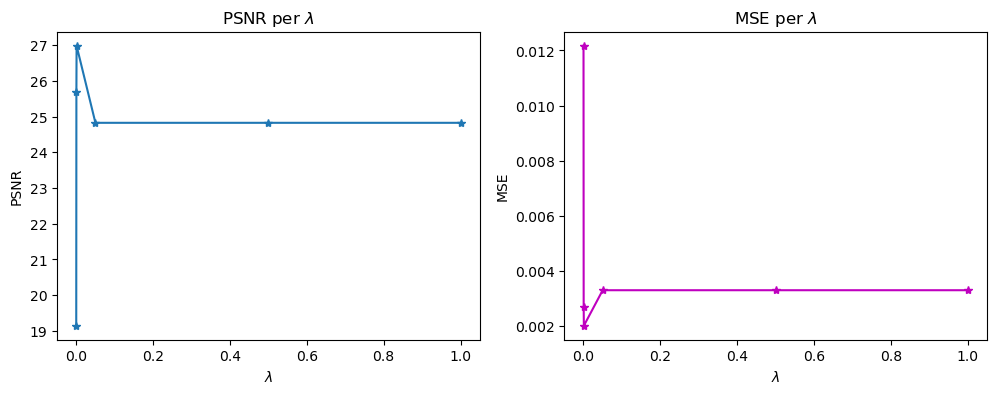

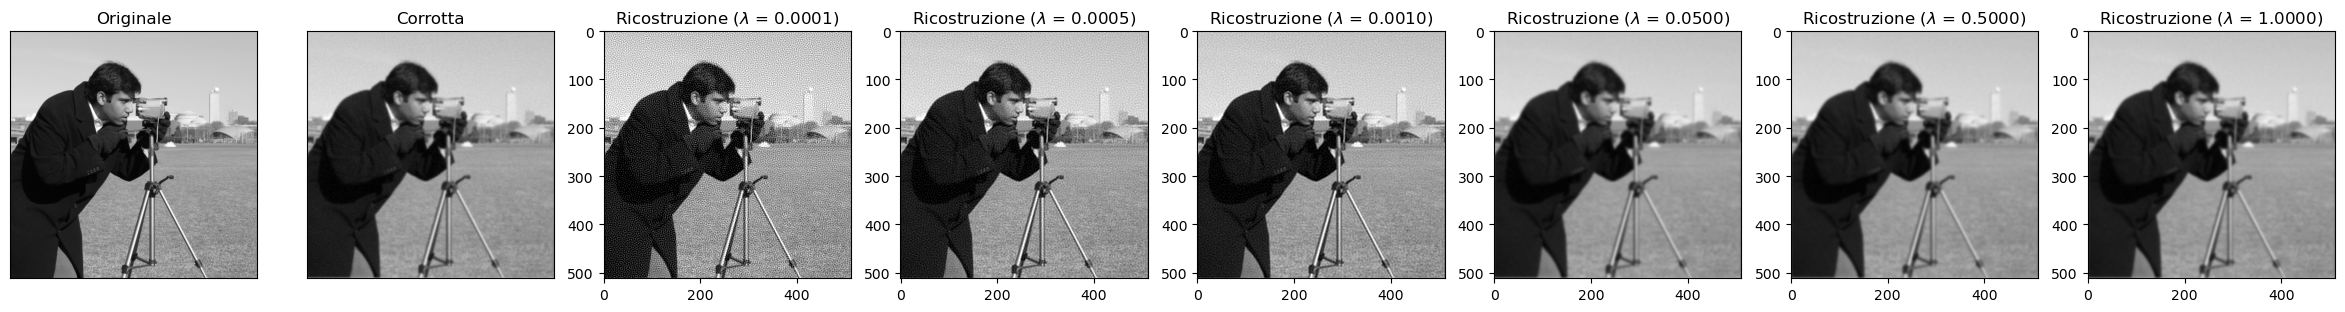

In [6]:
def f(x, L):
    x = x.reshape((m, n)) 
    nsq = totvar(x) 
    Ax = A(x, K, 1) 
    return 0.5 * np.sum(np.square(Ax - y)) + 0.5 * L * nsq 

def df(x, L):
    Lx = L * x 
    x = x.reshape(m, n)
    ATAx = AT(A(x, K, 1), K, 1) 
    d = ATAx - ATy 
    return d.reshape(m * n) + Lx 

x0 = ATy.reshape(m * n) 
lambdas = [0.0001, 0.0005, 0.001, 0.05, 0.5, 1] 
PSNRs = []  
mses = []
images = []

for i, L in enumerate(lambdas): 
    max_iter = 50 
    res = minimize(f, x0, (L), method='CG', jac=df, options={'maxiter': max_iter}) 

    X_curr = res.x.reshape(X.shape) 
    images.append(X_curr)

    PSNR = metrics.peak_signal_noise_ratio(X, X_curr)
    mse = metrics.mean_squared_error(X, X_curr)

    PSNRs.append(PSNR)
    mses.append(mse)
    print(f'PSNR: {PSNR:.3f} (\u03BB = {L})')
    print(f'MSE: {mse:.3f} (\u03BB = {L})')
    print('\n')
    

plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.plot(lambdas, PSNRs, '-*')
plt.title('PSNR per $\lambda$')
plt.ylabel("PSNR")
plt.xlabel('$\lambda$')

plt.subplot(122)
plt.plot(lambdas, mses, '-m*')
plt.title('MSE per $\lambda$')
plt.ylabel("MSE")
plt.xlabel('$\lambda$')
plt.show()

plt.figure(figsize=(30, 10))

plt.subplot(1, len(lambdas) + 2, 1).imshow(X, cmap='gray', vmin=0, vmax=1)
plt.title("Originale")
plt.xticks([]), plt.yticks([])
plt.subplot(1, len(lambdas) + 2, 2).imshow(y, cmap='gray', vmin=0, vmax=1)
plt.title("Corrotta")
plt.xticks([]), plt.yticks([])

for i, L in enumerate(lambdas):
    plt.subplot(1, len(lambdas) + 2, i + 3).imshow(images[i], cmap='gray', vmin=0, vmax=1)
    plt.title(f"Ricostruzione ($\lambda$ = {L:.4f})")
plt.show()